# Product Category Classifier — Training & Evaluation

Fine-tunes a ResNet-50 on Open Beauty Facts images to classify products into
**skincare**, **makeup**, or **haircare**.

---
## Setup

In [2]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [4]:
from torchvision import models, transforms

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns
import numpy as np
import pandas as pd

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import sys, json, random
from pathlib import Path

In [8]:
sys.path.insert(0, str(Path.cwd().parent))
from classifier.dataset import ProductDataset
from classifier.categories import CATEGORY_MAP

## 0. Build Datasets


In [9]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.build_dataset"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 21903: character maps to <undefined>


Tip: set HF_TOKEN env var for higher download rates from HuggingFace
Classified 10,451 products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\raw\manifest.csv
Downloaded 39/43 new images

Download summary:
  skincare: 7375
  haircare: 2328
  makeup: 748

Total: 10451 images



In [10]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.collect_unlabeled"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Exception in thread Thread-8 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 30802: character maps to <undefined>


Tip: set HF_TOKEN env var for higher download rates from HuggingFace
Found 47,959 unlabeled products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\unlabeled\unlabeled_manifest.csv
Downloaded 53/67 unlabeled images

Total unlabeled images available: 47955



## 1. Load Datasets

Train: 10569 | Val: 2264 | Test: 2264
Classes: ['haircare', 'makeup', 'skincare']
haircare: 4804
makeup: 575
skincare: 5190


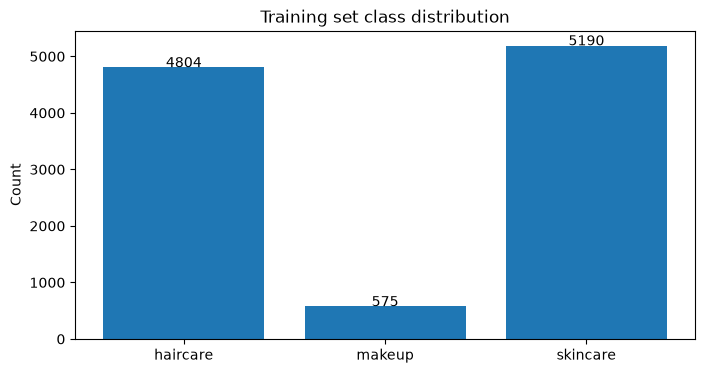

In [11]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

train_ds = ProductDataset(DATA_DIR, split="train")
val_ds   = ProductDataset(DATA_DIR, split="val")
test_ds  = ProductDataset(DATA_DIR, split="test")

test_loader = DataLoader(test_ds, 32, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {train_ds.classes}")

# Class distribution bar chart
counts = [sum(1 for _, l in train_ds.samples if l == i) for i in range(len(train_ds.classes))]
for cls, cnt in zip(train_ds.classes, counts):
    print(f"{cls}: {cnt}")
plt.figure(figsize=(8, 4))
plt.bar(train_ds.classes, counts)
plt.title("Training set class distribution")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

## 2. Train Model

In [12]:
from classifier.train import train_model

model, history, best_acc = train_model(
    train_ds, val_ds, DEVICE,
    epochs=20,
    unfreeze_layers=14,
)
print(f"\nBest validation accuracy: {best_acc:.2f}%")

Train: 10569 | Val: 2264 | Classes: ['haircare', 'makeup', 'skincare']


Epoch 1/20: 100%|██████████| 331/331 [00:32<00:00, 10.30it/s]


  Loss: 0.7680 / 0.7553 | Val Acc: 72.04% | LR: 1.00e-04


Epoch 2/20: 100%|██████████| 331/331 [00:30<00:00, 10.69it/s]


  Loss: 0.6597 / 0.7103 | Val Acc: 75.22% | LR: 1.00e-04


...

  Loss: 0.4704 / 0.6825 | Val Acc: 78.58% | LR: 5.00e-05


Epoch 15/20: 100%|██████████| 331/331 [00:31<00:00, 10.65it/s]


  Loss: 0.4640 / 0.6848 | Val Acc: 77.25% | LR: 5.00e-05


Epoch 16/20: 100%|██████████| 331/331 [00:31<00:00, 10.68it/s]


  Loss: 0.4578 / 0.7117 | Val Acc: 76.46% | LR: 5.00e-05
  Early stopping triggered (no improvement for 5 epochs)

Best validation accuracy: 78.93%


## 3. Training Curves

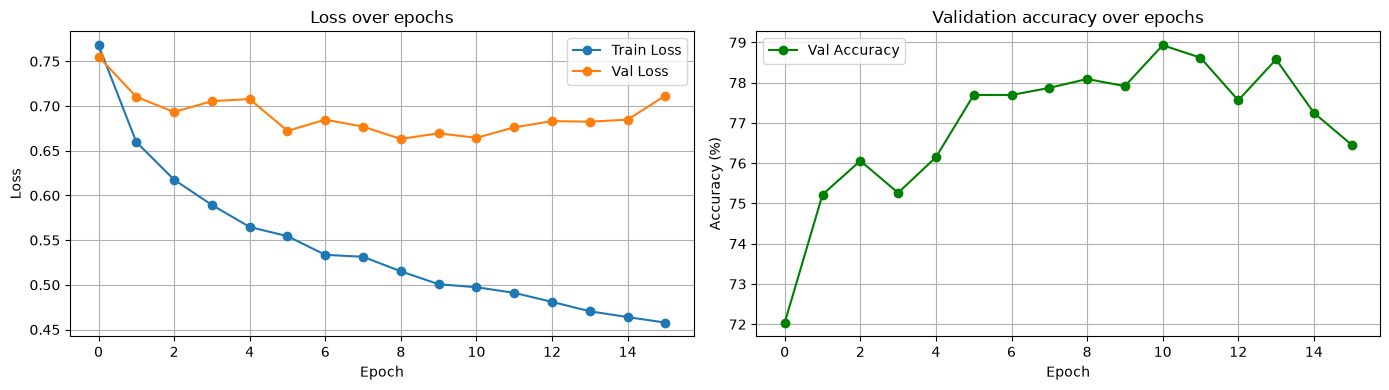

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history["val_acc"], label="Val Accuracy", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation accuracy over epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Test Set Evaluation

Testing: 100%|██████████| 71/71 [00:08<00:00,  8.80it/s]


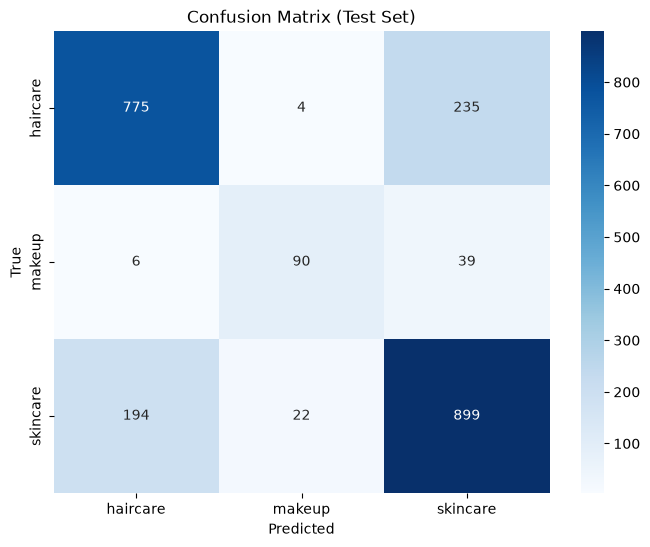

              precision    recall  f1-score   support

    haircare       0.79      0.76      0.78      1014
      makeup       0.78      0.67      0.72       135
    skincare       0.77      0.81      0.79      1115

    accuracy                           0.78      2264
   macro avg       0.78      0.75      0.76      2264
weighted avg       0.78      0.78      0.78      2264



In [14]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Per-class metrics
print(classification_report(all_labels, all_preds,
                            target_names=train_ds.classes))

## 5. Pseudo-label Unlabeled Images


In [15]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.pseudo_label"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Using device: cuda
Loaded model from C:\Projects\cosmetic-expiry-scanner\backend\data\models\resnet50_product_category.pt
Found 47,955 unlabeled images

Pseudo-labels above threshold (0.95): 4539
  haircare: 4386
  makeup: 98
  skincare: 55

Confidence stats:
  Mean: 0.9783
  Min:  0.9500
  Max:  1.0000

Copied 4539 pseudo-labeled images to C:\Projects\cosmetic-expiry-scanner\backend\data\raw

Dataset size now:
  haircare: 6825
  makeup: 847
  skincare: 7429
  Total: 15101
  (includes 4539 newly added pseudo-labels)



## 6. Retrain with Pseudo-Labeled Data


In [16]:
train_ds2 = ProductDataset(DATA_DIR, split='train')
val_ds2   = ProductDataset(DATA_DIR, split='val')
test_ds2  = ProductDataset(DATA_DIR, split='test')
test_loader2 = DataLoader(test_ds2, 32, shuffle=False)
total_train = len(train_ds2)
total_val = len(val_ds2)
total_test = len(test_ds2)
print('Train:', total_train, 'Val:', total_val, 'Test:', total_test)
print('Classes:', train_ds2.classes)
model2, history2, best_acc2 = train_model(train_ds2, val_ds2, DEVICE, epochs=20, unfreeze_layers=14)
print('Best validation accuracy:', best_acc2)

Train: 10571 Val: 2265 Test: 2265
Classes: ['haircare', 'makeup', 'skincare']
Train: 10571 | Val: 2265 | Classes: ['haircare', 'makeup', 'skincare']


Epoch 1/20: 100%|██████████| 331/331 [00:32<00:00, 10.28it/s]


  Loss: 0.7821 / 0.8163 | Val Acc: 67.81% | LR: 1.00e-04


Epoch 2/20: 100%|██████████| 331/331 [00:31<00:00, 10.47it/s]


  Loss: 0.6677 / 0.7223 | Val Acc: 74.88% | LR: 1.00e-04


...

  Loss: 0.5043 / 0.6827 | Val Acc: 77.66% | LR: 1.00e-04


Epoch 11/20: 100%|██████████| 331/331 [00:31<00:00, 10.65it/s]


  Loss: 0.5000 / 0.7032 | Val Acc: 77.70% | LR: 1.00e-04


Epoch 12/20: 100%|██████████| 331/331 [00:31<00:00, 10.56it/s]


  Loss: 0.4931 / 0.7086 | Val Acc: 75.63% | LR: 1.00e-04
  Early stopping triggered (no improvement for 5 epochs)
Best validation accuracy: 77.74834437086092


Testing: 100%|██████████| 71/71 [00:12<00:00,  5.85it/s]


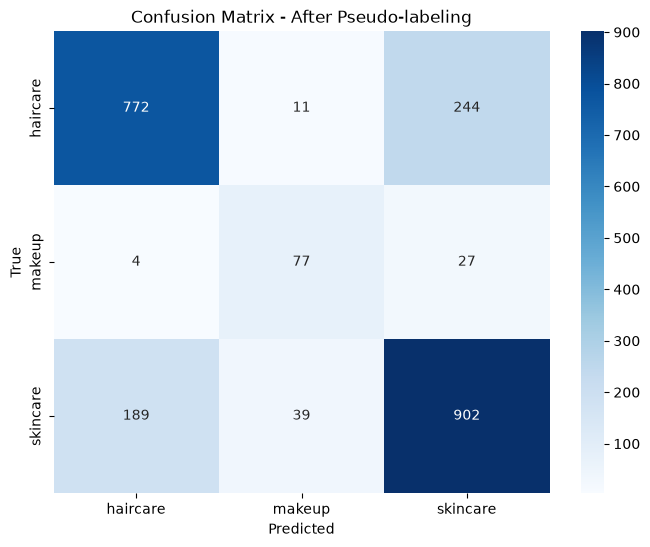

              precision    recall  f1-score   support

    haircare       0.80      0.75      0.78      1027
      makeup       0.61      0.71      0.66       108
    skincare       0.77      0.80      0.78      1130

    accuracy                           0.77      2265
   macro avg       0.73      0.75      0.74      2265
weighted avg       0.78      0.77      0.77      2265



In [17]:
model2.eval()
all_preds2 = []
all_labels2 = []
with torch.no_grad():
    for images, labels in tqdm(test_loader2, desc='Testing'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        all_preds2.extend(predicted.cpu().numpy())
        all_labels2.extend(labels.cpu().numpy())
cm2 = confusion_matrix(all_labels2, all_preds2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=train_ds2.classes, yticklabels=train_ds2.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - After Pseudo-labeling')
plt.show()
print(classification_report(all_labels2, all_preds2, target_names=train_ds2.classes))

## 7. Comparison vs Phase 5 Keyword Baseline

Run the keyword-based classifier from `extraction.py` on the same test set
to compare accuracy.

In [22]:
import subprocess, sys
from pathlib import Path

result = subprocess.run(
    [sys.executable, "-m", "classifier.compare_baselines"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

# ML accuracy from previous sections — fill in after running Sections 4 and 6
print()
print("Test accuracies to compare:")
print("  ML (before pseudo-labels):   78.0%")
print("  ML (after pseudo-labels):    77.0%")
print("  Keyword (product name):      <see above>")

=== Comparison: ML Classifier vs Keyword Baseline ===

Total images: 15101 | Test set: 2264

Fetching product names from HuggingFace dataset...
Found product names for 1782/2264 codes

Keyword Baseline Accuracy: 23.23% (414/1782)

Class        Keyword Acc  Count   
--------------------------------
haircare     33.4         661     
makeup       35.4         99      
skincare     15.5         1022    

Fill in ML accuracies from Sections 4 and 6 to complete the comparison.


Test accuracies to compare:
  ML (before pseudo-labels):   78.0%
  ML (after pseudo-labels):    77.0%
  Keyword (product name):      <see above>


## 8. Sample Predictions

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..1.2456646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1484594].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.5245317].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.64].
Cl

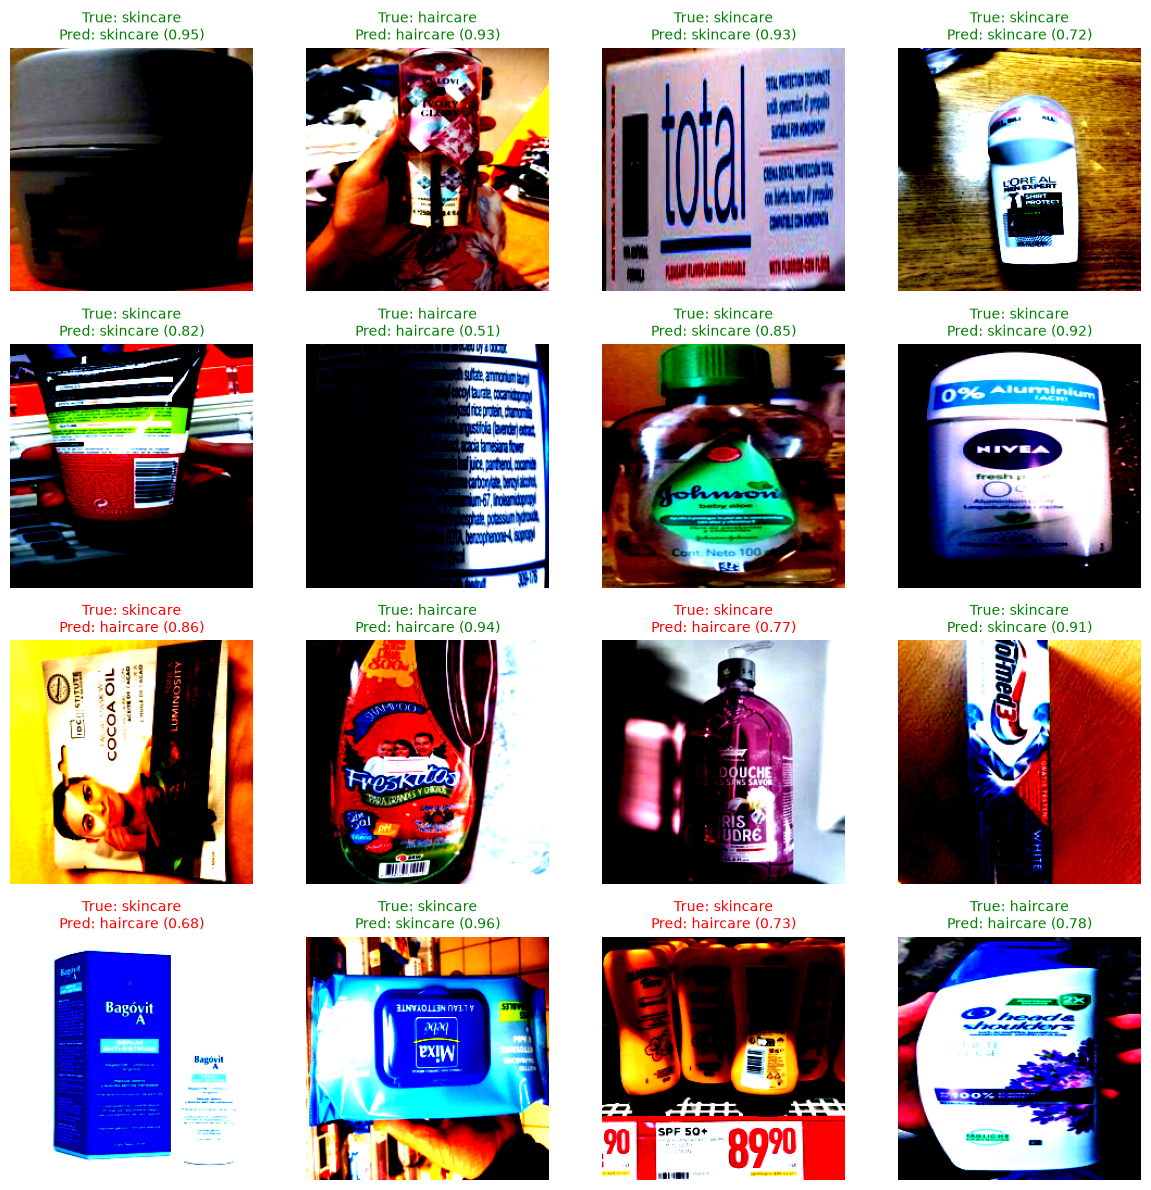

In [28]:
def imshow(img, title=""):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img, label = test_ds[int(i)]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(output, 1)
        conf, pred = prob.max(1)
    true_label = train_ds.classes[label]
    pred_label = train_ds.classes[pred.item()]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img.cpu().numpy().transpose((1, 2, 0)))
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf.item():.2f})",
                 color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()